# RNN
An RNN processes sequences (like text or time series) by maintaining a hidden state that captures information about previous time steps.
For a simple RNN:
$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b_h)$$ 
$$y_t = W_y h_t + b_y$$
Where:
* $x_t$: input at time step (t)
* $h_t$: hidden state
* $y_t$: output
* $W_x, W_h, W_y, b_h, b_y$: trainable weights
* tanh activation function

In [12]:
import math
import torch
import torch.nn as nn
from torch.nn import Parameter

In [14]:
# -------------------------
# RNN Cell 
# -------------------------
class RNNCell(nn.Module):
    """
    Single-step vanilla RNN cell:
    h_t = tanh(W_ih x_t + b_ih + W_hh h_{t-1} + b_hh)
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Input->hidden
        self.W_ih = Parameter(torch.randn(hidden_size, input_size) * (1.0 / math.sqrt(input_size))) #vanishing gradients
        self.b_ih = Parameter(torch.zeros(hidden_size))

        # Hidden->hidden
        self.W_hh = Parameter(torch.randn(hidden_size, hidden_size)  * (1.0 / math.sqrt(hidden_size))) #vanishing gradients
        self.b_hh = Parameter(torch.zeros(hidden_size))

    def forward(self, x_t, h_prev):
        # x_t: (batch, input_size)
        # h_prev: (batch, hidden_size)
        # Compute next hidden state
        pre = torch.matmul(x_t, self.W_ih.t()) + self.b_ih + torch.matmul(h_prev, self.W_hh.t()) + self.b_hh
        h_t = torch.tanh(pre)
        return h_t

In [15]:
import torch.optim as optim
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleRNN(nn.Module):
    """
    Processes whole sequences using RNNCell.
    Accepts input of shape (seq_len, batch, input_size) and returns outputs (seq_len, batch, output_size)
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn_cell = RNNCell(input_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, inputs, h0=None):
        """
        inputs: seq_len x batch x input_size
        h0: batch x hidden_size (optional)
        returns outputs: seq_len x batch x output_size, h_n: batch x hidden_size
        """
        seq_len, batch_size, _ = inputs.shape
        if h0 is None:
            h_t = torch.zeros(batch_size, self.hidden_size, device=inputs.device)
        else:
            h_t = h0

        outputs = []
        for t in range(seq_len):
            x_t = inputs[t]
            h_t = self.rnn_cell(x_t, h_t)          # update hidden
            y_t = self.output_layer(h_t)           # map to output
            outputs.append(y_t.unsqueeze(0))       # 1 x batch x out
        outputs = torch.cat(outputs, dim=0)        # seq_len x batch x output_size
        return outputs, h_t

In [16]:
# -------------------------
# Toy dataset: sine wave next-step prediction
# -------------------------
def generate_sine_sequences(seq_len, num_seqs, freq=1.0):
    xs = []
    ys = []
    for _ in range(num_seqs):
        # random phase and amplitude
        phase = np.random.rand() * 2 * np.pi
        amp = 0.5 + np.random.rand() * 1.0
        t = np.linspace(0 + phase, 2 * np.pi * freq + phase, seq_len + 1)
        series = amp * np.sin(t)
        # inputs are first seq_len, targets are next-step (1..seq_len)
        x = series[:-1].reshape(seq_len, 1)  # seq_len x 1
        y = series[1:].reshape(seq_len, 1)   # seq_len x 1
        xs.append(x)
        ys.append(y)
    xs = np.stack(xs, axis=1)  # seq_len x batch x 1
    ys = np.stack(ys, axis=1)  # seq_len x batch x 1
    return torch.tensor(xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.float32)

In [29]:
# !pip install matplotlib

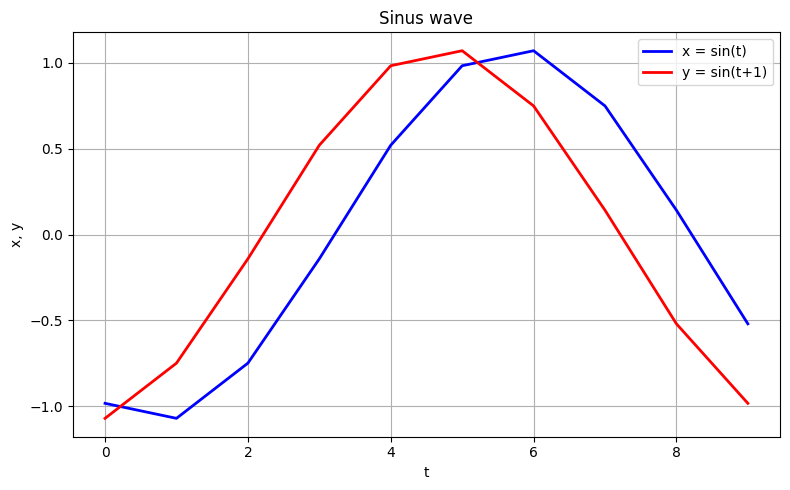

In [35]:
import matplotlib.pyplot as plt
(x, y) =  generate_sine_sequences(seq_len=10, num_seqs=1, freq=1.0)
x_n = x[:,0].numpy()
y_n = y[:,0].numpy()

# Plot results
plt.figure(figsize=(8,5))
plt.plot(x_n, label='x = sin(t)', color='blue', linewidth=2)
plt.plot(y_n, label='y = sin(t+1)', color='red', linewidth=2)
plt.xlabel("t")
plt.ylabel("x, y")
plt.title("Sinus wave")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# -------------------------
# Training routine
# -------------------------
def train_model(model, num_epochs=300, seq_len=50, batch_size=32, lr=1e-3, clip=1.0):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(1, num_epochs+1):
        model.train()
        # generate fresh batch each epoch
        inputs, targets = generate_sine_sequences(seq_len, batch_size)
        inputs = inputs.to(device)    # seq_len x batch x 1
        targets = targets.to(device)  # seq_len x batch x 1

        optimizer.zero_grad()
        outputs, _ = model(inputs)           # seq_len x batch x 1
        loss = criterion(outputs, targets)
        loss.backward()
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        if epoch % 25 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{num_epochs}  Loss: {loss.item():.6f}")

    # return trained model
    return model



In [19]:
torch.manual_seed(0)
np.random.seed(0)

input_size = 1
hidden_size = 64
output_size = 1
seq_len = 50
batch_size = 64

print("Training Vanilla RNN (manual cell)...")
rnn = SimpleRNN(input_size, hidden_size, output_size)
rnn = train_model(rnn, num_epochs=300, seq_len=seq_len, batch_size=batch_size, lr=1e-3)

# Evaluate on a new sine
rnn.eval()
with torch.no_grad():
    test_x, test_y = generate_sine_sequences(seq_len, 1)
    test_x = test_x.to(device)
    test_y = test_y.to(device)
    out, _ = rnn(test_x)
    out = out.squeeze(-1).cpu().numpy()   # seq_len x
    target = test_y.squeeze(-1).cpu().numpy()
    print("\nExample predictions (first 10 steps):")
    for i in range(10):
        print(f"step {i:02d}: pred {out[i,0]:+.4f}  target {target[i,0]:+.4f}")



Training Vanilla RNN (manual cell)...
Epoch 1/300  Loss: 0.174254
Epoch 25/300  Loss: 0.007405
Epoch 50/300  Loss: 0.002762
Epoch 75/300  Loss: 0.002015
Epoch 100/300  Loss: 0.001342
Epoch 125/300  Loss: 0.001108
Epoch 150/300  Loss: 0.001181
Epoch 175/300  Loss: 0.000897
Epoch 200/300  Loss: 0.000939
Epoch 225/300  Loss: 0.000980
Epoch 250/300  Loss: 0.000867
Epoch 275/300  Loss: 0.000756
Epoch 300/300  Loss: 0.000784

Example predictions (first 10 steps):
step 00: pred +0.6304  target +0.4440
step 01: pred +0.4461  target +0.3776
step 02: pred +0.3245  target +0.3052
step 03: pred +0.2231  target +0.2280
step 04: pred +0.1310  target +0.1472
step 05: pred +0.0504  target +0.0641
step 06: pred -0.0361  target -0.0201
step 07: pred -0.1360  target -0.1039
step 08: pred -0.1872  target -0.1860
step 09: pred -0.2839  target -0.2653
